# Maestría en Inteligencia Artificial y Analítica de Datos

## Programación para Analítica Descriptiva y Predictiva - Marzo 2025
## Práctica: Práctica: Regresión Lineal Múltiple
---


## Datos del Estudiante

*   Apellidos y Nombre: Quintero Octavio
*   Matrícula: 266226

---


** Regresión lineal con datos categóricos: Costos, Localidades y Salarios**

📌 Objetivos de la Práctica:
Al finalizar esta práctica, los estudiantes serán capaces de:

- Codificar variables categóricas usando one-hot encoding con K-1 para problemas de regresión
- Realizar AED
- Construir un modelo de regresión con variables dummy
- Interpretar los resultados de los coeficientes
- Analizar los resultados de los errores residuales
- Calcular el desempeño del modelo de regresión.

Problema: Se podría argumentar que el salario está relacionado con el costo de la educación. Por lo tanto, para analizar este argumentos veremos qué sucede cuando usamos las variables independientes cost y location.

# 1. Carga de datos

Carga el conjunto de datos college.csv, que está en campus virtual, en un dataframe. Elige de este conjunto las columnas salary (variable dependiente), cost(variable independiente - numérica) y location (variable independiente categórica).

Realiza lo siguiente:

*   Convierte si es necesario la variable location a tipo de dato categórico
*   Usa la instrucción describe() en las variables salary y cost
* Cuenta la cantidad de datos que hay por categoría en location
* Convierte la variable location usando one-hot encoding



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

# Cargar datos
df = pd.read_csv("/content/drive/MyDrive/ClassFiles/college.csv")

# Seleccionar variables
df = df[['salary', 'cost', 'location']]

# Revisar tipos
print(df.dtypes)

salary       int64
cost         int64
location    object
dtype: object


In [3]:
df['location'] = df['location'].astype('category')

In [4]:
print(df[['salary', 'cost']].describe())

              salary           cost
count      85.000000      85.000000
mean    95898.823529  142434.470588
std     11937.121912   53913.064578
min     74900.000000   18260.000000
25%     87100.000000   84670.000000
50%     93200.000000  169200.000000
75%    105000.000000  188700.000000
max    123000.000000  227300.000000


In [5]:
print(df['location'].value_counts())

location
NE    25
W     21
S     20
MW    19
Name: count, dtype: int64


In [6]:
df_encoded = pd.get_dummies(df, columns=['location'], drop_first=True)
print(df_encoded.head())

   salary    cost  location_NE  location_S  location_W
0  119000  189300         True       False       False
1  121000  189600         True       False       False
2  123000  188400         True       False       False
3  123000  188700         True       False       False
4  110000  194200         True       False       False


# 2. Análisis Exploratorio de los Datos

Realiza un análisis exploratorio de los datos y discute lo que observas en cada gráfica.


*   Crea un histograma de la columna salary. Discute lo que observas
* Crea un diagrama de dispersión de salary vs cost, considerando lo siguiente: para cada punto elegirás un color que represente la localidad en la que está el salario y el costo de la educación. Por lo tanto el diagrama de dispersión debería tener puntos en 4 colores distintos. Discute lo que observas
* Emplea un boxplot para saber si hay diferencias en los costos según la ubicación, es decir, con boxplot deberás analizar la distribución de cost por localidad. Discute lo que observas




In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

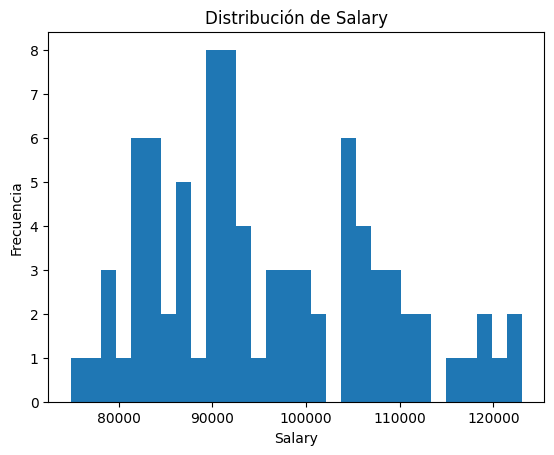

In [8]:
plt.hist(df['salary'], bins=30)
plt.title("Distribución de Salary")
plt.xlabel("Salary")
plt.ylabel("Frecuencia")
plt.show()

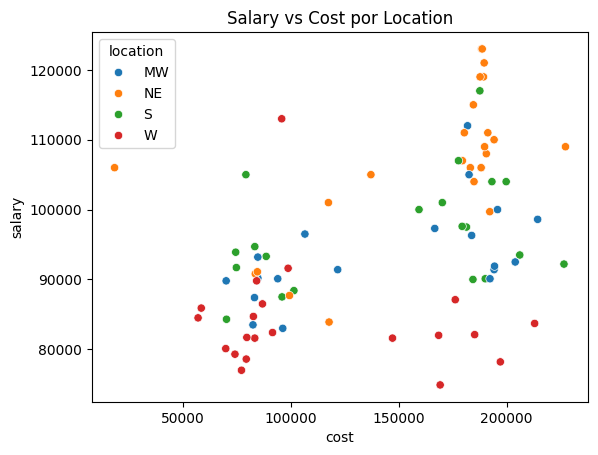

In [9]:
sns.scatterplot(data=df, x='cost', y='salary', hue='location')
plt.title("Salary vs Cost por Location")
plt.show()

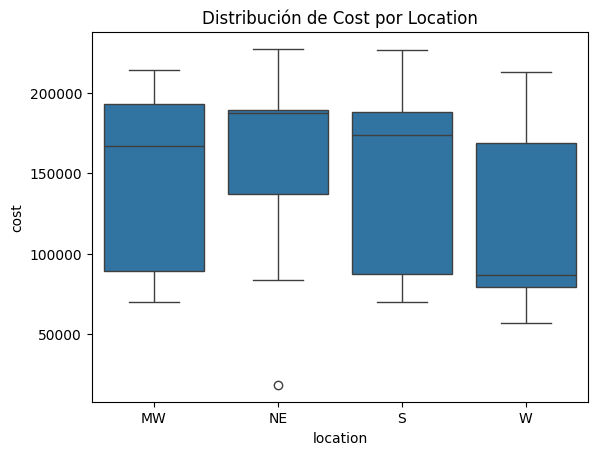

In [10]:
sns.boxplot(data=df, x='location', y='cost')
plt.title("Distribución de Cost por Location")
plt.show()

# 3. Construcción del modelo de regresión

- Construye el modelo de regresión usando los datos de salario, costo y location. Recuerda que esta última debe ser en su versión codificada con one-hot encoding.
- Imprime los coeficientes e interpreta qué significan cuando se sustituyen valores en costo, y location (versión codificada). Si no recuerdas cómo se hace esta interpretación consulta los videos.


In [11]:
from sklearn.linear_model import LinearRegression

X = df_encoded.drop('salary', axis=1)
y = df_encoded['salary']

model = LinearRegression()
model.fit(X, y)

# Coeficientes
coef_df = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': model.coef_
})
print(coef_df)

print("Intercepto:", model.intercept_)

      Variable   Coeficiente
0         cost      0.060518
1  location_NE  12032.819692
2   location_S   2800.345026
3   location_W  -7721.420103
Intercepto: 84988.71622754404


El modelo es como:

salary=β0+β1(cost)+β2(location1)+β3(location2)+...

cost: cuánto cambia el salario por cada unidad adicional de costo
location_X: diferencia de salario respecto a la categoría base

# 4. Análisis de Residuos

- Construyen una visualización de predicciones (salario estimado) vs valores reales (salario real).
- Crea una gráfica de los errores residuales. Discute lo que observas

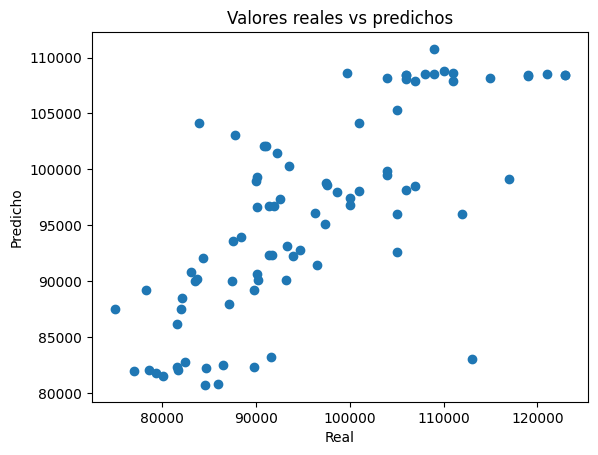

In [12]:
y_pred = model.predict(X)

plt.scatter(y, y_pred)
plt.xlabel("Real")
plt.ylabel("Predicho")
plt.title("Valores reales vs predichos")
plt.show()

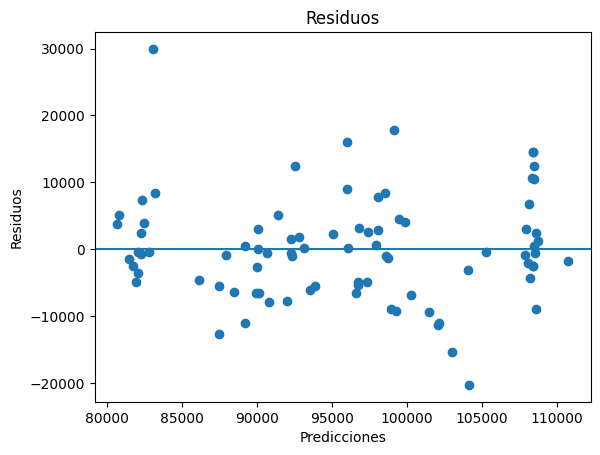

In [13]:
residuals = y - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicciones")
plt.ylabel("Residuos")
plt.title("Residuos")
plt.show()

# 5. Evalúa el modelo

- Calcula el MSE del modelo construido. Recuerda que usas el propio conjunto de datos (No hablamos nada de entrenamiento y test).
- Calcula el R² Score

Discute estos resultados obtenidos.

In [14]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print("MSE:", mse)
print("R2:", r2)

MSE: 60480269.14657189
R2: 0.5705089716684086


MSE:
Qué tan grande es el error promedio
Más bajo = mejor
R²:
Qué proporción de la variabilidad explica el modelo
0 → nada
1 → perfecto

# 6. Realiza un análisis de varianza con stastmodel

Consulta esto aquí https://www.statsmodels.org/dev/examples/notebooks/generated/variance_components.html

In [15]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Usamos la versión sin encoding automático
model_sm = ols('salary ~ cost + C(location)', data=df).fit()

anova_table = sm.stats.anova_lm(model_sm, typ=2)
print(anova_table)

                   sum_sq    df          F        PR(>F)
C(location)  4.071774e+09   3.0  21.121259  3.570975e-10
cost         7.878166e+08   1.0  12.259774  7.600629e-04
Residual     5.140823e+09  80.0        NaN           NaN


PR(>F):

Si < 0.05 → variable significativa

El salario funciona como un sistema con varias palancas: el costo de la educación es una importante, pero no la única. La ubicación actúa como un “filtro invisible” que modifica tanto costos como resultados, y el modelo logra capturar parte de este comportamiento, aunque deja claro que hay más variables en juego.